In [68]:
import numpy as np
import matplotlib.pyplot as plt
import os
import wandb
import seaborn as sns
import pprint
import traceback
import numpy as np
import pandas as pd
from collections import defaultdict
import pickle # For caching
import os     # For checking cache file existence

# pip install rliable
from rliable import metrics, library as rly
from rliable import plot_utils 

WANDB_ENTITY_NAME="clvr"
WANDB_PROJECT_NAME="roboclip-v2"

# tasks are the tasks that we want to plot
TASKS = ["button-press-wall-v2", "coffee-button-v2", "window-close-v2", "reach-wall-v2", "faucet-close-v2"]

# methods_dict maps from group prefix (for finding the right group) to method name used for plot labeling
METHODS_DICT = dict(
    sparse_rlpd="Sparse",
    #liv_rlpd="LIV",
    rewind_rlpd="ReWiND",
)

# use the group suffixes to select the suffix corresponding to the method
GROUP_SUFFIXES=dict(
    sparse_rlpd="online_final",
    #liv_rlpd="online_final",
    rewind_rlpd="final",
)

color_palette = sns.color_palette('colorblind')
color_dict = dict(zip(METHODS_DICT.values(), color_palette))

# auto generate WANDB_GROUP_NAMES based on {PREFIX}_{TASK}_{SUFFIX} over all tasks
# generate a list of all task wandb group names for each method:
METHOD_TO_WANDB_NAME= dict()
for method in METHODS_DICT.keys():
    method_name = METHODS_DICT[method]
    METHOD_TO_WANDB_NAME[method_name] = []
    for task in TASKS:
        METHOD_TO_WANDB_NAME[method_name].append(f"{method}_{task}_{GROUP_SUFFIXES[method]}")
pprint.pp(METHOD_TO_WANDB_NAME)

NAN_VAL = -0.05

{'Sparse': ['sparse_rlpd_button-press-wall-v2_online_final',
            'sparse_rlpd_coffee-button-v2_online_final',
            'sparse_rlpd_window-close-v2_online_final',
            'sparse_rlpd_reach-wall-v2_online_final',
            'sparse_rlpd_faucet-close-v2_online_final'],
 'ReWiND': ['rewind_rlpd_button-press-wall-v2_final',
            'rewind_rlpd_coffee-button-v2_final',
            'rewind_rlpd_window-close-v2_final',
            'rewind_rlpd_reach-wall-v2_final',
            'rewind_rlpd_faucet-close-v2_final']}


In [24]:
# --- Cache Configuration ---
CACHE_FILE = "wandb_metaworld_cache.pkl"

# --- Initialize Data Structures ---
# Final values (populated from cache or fetched)
method_task_success_rates = {
    method_name: {task: [] for task in TASKS}
    for method_name in METHODS_DICT.values()
}
method_task_eval_returns = {
    method_name: {task: [] for task in TASKS}
    for method_name in METHODS_DICT.values()
}
# History data (populated from cache or fetched)
method_task_success_history = {
    method_name: {task: [] for task in TASKS}
    for method_name in METHODS_DICT.values()
}
method_task_reward_history = {
    method_name: {task: [] for task in TASKS}
    for method_name in METHODS_DICT.values()
}

# --- Load Cache ---
run_cache = {} # Structure: {run_id: {'state': ..., 'summary': ..., 'history_success': df, 'history_reward': df}}
if os.path.exists(CACHE_FILE):
    print(f"Loading cache from {CACHE_FILE}...")
    try:
        with open(CACHE_FILE, 'rb') as f:
            run_cache = pickle.load(f)
        print(f"Loaded {len(run_cache)} runs from cache.")
    except Exception as e:
        print(f"Warning: Could not load cache file {CACHE_FILE}. Error: {e}. Starting with empty cache.")
        run_cache = {}
else:
    print("No cache file found. Will fetch all runs.")

# Initialize the wandb API
# Consider increasing timeout if experiencing frequent API timeouts
try:
    api = wandb.Api(timeout=120)
    print("WandB API initialized.")
except Exception as api_e:
    print(f"Fatal Error: Could not initialize WandB API: {api_e}")
    # Depending on your workflow, you might want to raise an exception or exit here
    # raise api_e

print(f"\nFetching runs from project: {WANDB_ENTITY_NAME}/{WANDB_PROJECT_NAME}")
print("-" * 30)

# --- Data Fetching and Caching Loop ---
needs_cache_save = False # Flag to save cache only if changes were made. Don't touch manually.

# Iterate through the defined WandB group names and associated method display names
for method_display_name, group_name_list in METHOD_TO_WANDB_NAME.items():
    # Iterate through group names, which correspond to tasks in order
    for task_index, group_name in enumerate(group_name_list):
        # Ensure task_index is within bounds of TASKS list
        if task_index >= len(TASKS):
            print(f"  Warning: Task index {task_index} out of bounds for TASKS list. Skipping group {group_name}.")
            continue

        task_name = TASKS[task_index] # Get task name from TASKS list using index
        print(f"\nProcessing Task: {task_name}, Group: {group_name} (Method: {method_display_name})")

        # Reset lists for the current task/method before populating from cache/API
        method_task_success_rates[method_display_name][task_name] = []
        method_task_eval_returns[method_display_name][task_name] = []
        method_task_success_history[method_display_name][task_name] = []
        method_task_reward_history[method_display_name][task_name] = []

        try:
            # Fetch basic run info (id, name, state) for the group
            # Add error handling for the API call itself
            try:
                 runs_in_group = api.runs(f"{WANDB_ENTITY_NAME}/{WANDB_PROJECT_NAME}", filters={"group": group_name})
            except Exception as api_runs_e:
                 print(f"  !! Error fetching runs for group {group_name} from API: {api_runs_e}")
                 continue # Skip this group if API fails

            if not runs_in_group:
                print(f"  No runs found for group: {group_name} via API.")
                continue

            print(f"  Found {len(runs_in_group)} runs in API for group {group_name}. Checking cache/fetching...")
            runs_processed_in_group = 0
            for run in runs_in_group:
                run_id = run.id
                run_state = run.state
                run_name = run.name # For better logging
                print(f"    Run: {run_name} ({run_id}), State: {run_state}", end='')

                # Data containers for this specific run
                summary_data = {}
                success_hist_df = None
                reward_hist_df = None

                # Check cache
                cached_run_data = run_cache.get(run_id)

                # Determine if we need to fetch data
                fetch_needed = True
                if cached_run_data and cached_run_data.get('state') == 'finished' and run_state == 'finished':
                    print(" -> Finished in cache. Using cached data.")
                    summary_data = cached_run_data.get('summary', {})
                    success_hist_df = cached_run_data.get('history_success')
                    reward_hist_df = cached_run_data.get('history_reward')
                    fetch_needed = False
                elif cached_run_data:
                    print(f" -> Cache state '{cached_run_data.get('state')}' differs or run state '{run_state}' not finished. Fetching...")
                else:
                    print(" -> Not in cache. Fetching...")

                if fetch_needed:
                    try:
                        # Fetch summary (might be slow if not cached by wandb client)
                        run_summary = run.summary
                        final_success_rate = run_summary.get('eval/success_rate', None)
                        final_eval_return = run_summary.get('eval/mean_reward', None)
                        summary_data = {
                            'eval/success_rate': final_success_rate,
                            'eval/mean_reward': final_eval_return
                        }

                        # Fetch history using scan_history (more efficient for large histories)
                        print(" Scanning history...", end='')
                        history_scan = run.scan_history(keys=['num_timesteps', 'eval/success_rate', 'eval/mean_reward'])
                        history_data = list(history_scan) # Convert iterator to list
                        print(f" {len(history_data)} rows.", end='')

                        if history_data:
                            history_df = pd.DataFrame(history_data)
                            if 'num_timesteps' in history_df.columns:
                                history_df = history_df.dropna(subset=['num_timesteps']).sort_values(by='num_timesteps').reset_index(drop=True)

                                # Process success history
                                if 'eval/success_rate' in history_df.columns:
                                    temp_df = history_df[['num_timesteps', 'eval/success_rate']].dropna(subset=['eval/success_rate'])
                                    if not temp_df.empty:
                                        success_hist_df = temp_df

                                # Process reward history
                                if 'eval/mean_reward' in history_df.columns:
                                    temp_df = history_df[['num_timesteps', 'eval/mean_reward']].dropna(subset=['eval/mean_reward'])
                                    if not temp_df.empty:
                                        reward_hist_df = temp_df
                            else:
                                print(f" Warning: 'num_timesteps' missing.", end='')

                        # Update cache only if the run is finished
                        if run_state == 'finished':
                            # Ensure DataFrames are serializable (usually are, but good practice)
                            cache_entry = {
                                'state': run_state,
                                'summary': summary_data,
                                'history_success': success_hist_df,
                                'history_reward': reward_hist_df
                            }
                            # Check if cache entry changed before marking save needed
                            if run_id not in run_cache or run_cache[run_id] != cache_entry:
                                run_cache[run_id] = cache_entry
                                needs_cache_save = True
                                print(" -> Stored/Updated finished run in cache.", end='')
                        else:
                             print(f" -> State '{run_state}', not caching.", end='')
                             # If run was previously cached (must have been finished then), remove it
                             if run_id in run_cache:
                                 print(f" Removing outdated cache entry.", end='')
                                 del run_cache[run_id]
                                 needs_cache_save = True
                        print() # Newline after status message

                    except Exception as fetch_e:
                        print(f"\n      !! Error fetching full data for run {run_id} ({run_name}): {fetch_e}")
                        traceback.print_exc() # Print traceback for fetch errors
                        continue # Skip appending data for this run

                # --- Append data (from cache or fresh fetch) to task lists ---
                final_success = summary_data.get('eval/success_rate')
                final_return = summary_data.get('eval/mean_reward')

                # Append final values if valid
                if final_success is not None and not np.isnan(final_success):
                    method_task_success_rates[method_display_name][task_name].append(final_success)
                if final_return is not None and not np.isnan(final_return):
                     method_task_eval_returns[method_display_name][task_name].append(final_return)

                # Append history DataFrames if they exist
                if success_hist_df is not None and not success_hist_df.empty:
                     method_task_success_history[method_display_name][task_name].append(success_hist_df)
                if reward_hist_df is not None and not reward_hist_df.empty:
                     method_task_reward_history[method_display_name][task_name].append(reward_hist_df)

                runs_processed_in_group += 1

            print(f"  Group {group_name} finished. Populated data for {runs_processed_in_group} runs.")

        except Exception as e:
            print(f"!!! Major Error processing group {group_name}: {e}")
            traceback.print_exc()

# --- Save Cache (if updated) ---
if needs_cache_save:
    print(f"\nSaving updated cache ({len(run_cache)} finished runs) to {CACHE_FILE}...")
    try:
        with open(CACHE_FILE, 'wb') as f:
            pickle.dump(run_cache, f)
        print("Cache saved successfully.")
    except Exception as e:
        print(f"Error saving cache: {e}")
else:
    print(f"\nCache file '{CACHE_FILE}' not modified. No need to save.")


# --- Final Output ---
print("\n" + "=" * 30)
print("Final Aggregated Results per Method and Task (from Cache/Fetch):")
print("=" * 30)
for method, task_data_success in method_task_success_rates.items():
    print(f"\nMethod: {method}")
    print("-" * 20)
    task_data_returns = method_task_eval_returns.get(method, {})
    task_data_hist_succ = method_task_success_history.get(method, {})
    task_data_hist_ret = method_task_reward_history.get(method, {})

    method_has_data = False
    for task in TASKS: # Iterate through all possible tasks to ensure structure
        rates = task_data_success.get(task, [])
        returns = task_data_returns.get(task, [])
        success_hist_list = task_data_hist_succ.get(task, [])
        reward_hist_list = task_data_hist_ret.get(task, [])
        num_success_hist = len(success_hist_list)
        num_reward_hist = len(reward_hist_list)

        # Only print task header if there's some data for it
        if rates or returns or num_success_hist or num_reward_hist:
            method_has_data = True
            print(f"  Task: {task}")
            if rates:
                print(f"    Final Success Rates ({len(rates)} runs): {rates}")
                try:
                     print(f"      Average: {np.mean(rates):.4f}, Median: {np.median(rates):.4f}")
                except Exception as stat_e:
                     print(f"      Could not calculate stats for rates: {stat_e}")
            else:
                print(f"    No valid final success rates found.")

            if returns:
                 print(f"    Final Eval Returns ({len(returns)} runs): {returns}")
                 try:
                     print(f"      Average: {np.mean(returns):.4f}, Median: {np.median(returns):.4f}")
                 except Exception as stat_e:
                      print(f"      Could not calculate stats for returns: {stat_e}")
            else:
                 print(f"    No valid final eval returns found.")

            print(f"    Collected History Series: Success Rate ({num_success_hist}), Eval Return ({num_reward_hist})")

    if not method_has_data:
         print("  No data found for this method across all tasks.")
    print("-" * 20)

print("=" * 30)
print(f"\nNote: Data is stored in the respective `method_task_...` dictionaries.")
print("History data contains lists of pandas DataFrames per method and task.")
print(f"Finished runs are cached in {CACHE_FILE}")
print("=" * 30)


Loading cache from wandb_metaworld_cache.pkl...
Loaded 16 runs from cache.
WandB API initialized.

Fetching runs from project: clvr/roboclip-v2
------------------------------

Processing Task: button-press-wall-v2, Group: sparse_rlpd_button-press-wall-v2_online_final (Method: Sparse)
  Found 3 runs in API for group sparse_rlpd_button-press-wall-v2_online_final. Checking cache/fetching...
    Run: metaworld_off_on_15_sparse_wsrl_iql_n_critics_10_n_critics_to_sample_2_train_critic_with_entropy_False_utd_4_use_proprio__seed_button-press-wall-v2_seed_32_sparse (1u1rv82c), State: finished -> Finished in cache. Using cached data.
    Run: metaworld_off_on_15_sparse_wsrl_iql_n_critics_10_n_critics_to_sample_2_train_critic_with_entropy_False_utd_4_use_proprio__seed_button-press-wall-v2_seed_42_sparse (2w8snpzh), State: finished -> Finished in cache. Using cached data.
    Run: metaworld_off_on_15_sparse_wsrl_iql_n_critics_10_n_critics_to_sample_2_train_critic_with_entropy_False_utd_4_use_propr

In [33]:
# Aggregate results, excluding tasks that are incomplete or inconsistent across methods.

print("Validating tasks across all methods...")

task_run_counts = {task: {} for task in TASKS}
invalid_tasks = set()
valid_tasks_initial_check = [] # Tasks that pass initial checks per method

# --- Task Validation Pass ---
for task_name in TASKS:
    print(f"  Checking task: {task_name}")
    counts_for_this_task = []
    task_potentially_valid = True
    methods_with_data_for_task = []

    for method_name in METHODS_DICT.values():
        success_rates = method_task_success_rates.get(method_name, {}).get(task_name)
        eval_returns = method_task_eval_returns.get(method_name, {}).get(task_name)

        # Check 1: Data existence (list is not None and not empty)
        if success_rates is None or eval_returns is None or not success_rates or not eval_returns:
            print(f"    -> Invalidating task: Missing data for method '{method_name}'.")
            invalid_tasks.add(task_name)
            task_potentially_valid = False
            break # Invalidate this task for all methods, move to the next task

        # Check 2: Length mismatch (internal consistency check)
        if len(success_rates) != len(eval_returns):
            print(f"    -> Invalidating task: Mismatch in run counts for method '{method_name}' (Succ: {len(success_rates)}, Ret: {len(eval_returns)}).")
            invalid_tasks.add(task_name)
            task_potentially_valid = False
            break

        # Store count if valid so far for this method
        task_run_counts[task_name][method_name] = len(success_rates)
        counts_for_this_task.append(len(success_rates))
        methods_with_data_for_task.append(method_name)

    # Proceed only if the task hasn't been invalidated by missing data/mismatch
    if task_potentially_valid:
        # Check 3: Consistency of run counts across all methods *that have data* for this task
        if not counts_for_this_task: # Should not happen if we have methods
             print(f"    -> Invalidating task: No run counts found (Error?).")
             invalid_tasks.add(task_name)
        #elif len(set(counts_for_this_task)) > 1:
        #    print(f"    -> Invalidating task: Inconsistent run counts across methods: {dict(zip(methods_with_data_for_task, counts_for_this_task))}.")
        #    invalid_tasks.add(task_name)
        elif counts_for_this_task[0] == 0: # All methods had 0 runs
             print(f"    -> Invalidating task: Task has 0 runs for all methods.")
             invalid_tasks.add(task_name)
        else:
            # Task passed all checks
            print(f"    -> Task potentially valid with {counts_for_this_task[0]} runs per method.")
            valid_tasks_initial_check.append(task_name)


# --- Determine Final Valid Tasks and Run Count ---
# Final valid tasks are those not in the invalid set
valid_tasks = sorted([task for task in TASKS if task not in invalid_tasks])
num_valid_tasks = len(valid_tasks)
num_runs = 0 # Initialize num_runs

if not valid_tasks:
    print("\nNo tasks found to be valid and consistent across all methods. Cannot proceed with aggregation.")
    final_aggregate_success_rates = {}
    final_aggregate_eval_returns = {}
else:
    # Determine the consistent number of runs using the first valid task and first method
    first_valid_task = valid_tasks[0]
    # Find the first method that actually has data for this task (should exist)
    first_method = next(iter(task_run_counts[first_valid_task]))
    num_runs = task_run_counts[first_valid_task][first_method]

    print(f"\nAggregating based on {num_valid_tasks} valid tasks: {valid_tasks}")
    print(f"Consistent number of runs per task/method: {num_runs}")
    print(f"Expected shape per method: ({num_runs}, {num_valid_tasks})")

    # --- Data Aggregation Pass ---
    final_aggregate_success_rates = dict()
    final_aggregate_eval_returns = dict()

    for method_name in METHODS_DICT.values():
        success_data_for_method = []
        return_data_for_method = []
        valid_method_data = True

        for task_name in valid_tasks:
            # Data should exist and have the correct length based on the validation pass
            s_rates = method_task_success_rates.get(method_name, {}).get(task_name, [])
            e_returns = method_task_eval_returns.get(method_name, {}).get(task_name, [])

            if len(s_rates) != num_runs or len(e_returns) != num_runs:
                 # This check is mostly a safeguard; should be caught earlier.
                 print(f"  Error: Data length mismatch for method '{method_name}', task '{task_name}' during aggregation. Expected {num_runs}, got {len(s_rates)}/{len(e_returns)}. Skipping method '{method_name}'.")
                 valid_method_data = False
                 # Clean up potentially added keys for this method if error occurs
                 if method_name in final_aggregate_success_rates: del final_aggregate_success_rates[method_name]
                 if method_name in final_aggregate_eval_returns: del final_aggregate_eval_returns[method_name]
                 break # Stop processing tasks for this method

            success_data_for_method.append(s_rates)
            return_data_for_method.append(e_returns)

        if not valid_method_data:
            continue # Skip to the next method if an error occurred

        # Convert list of lists (num_valid_tasks x num_runs) to NumPy array and transpose
        try:
            # Shape before T: (num_valid_tasks, num_runs)
            aggregate_success = np.array(success_data_for_method).T
            aggregate_returns = np.array(return_data_for_method).T
            # Shape after T: (num_runs, num_valid_tasks)

            # Final shape check
            if aggregate_success.shape == (num_runs, num_valid_tasks) and aggregate_returns.shape == (num_runs, num_valid_tasks):
                 final_aggregate_success_rates[method_name] = aggregate_success
                 final_aggregate_eval_returns[method_name] = aggregate_returns
            else:
                 print(f"  Error: Unexpected shape after final aggregation for '{method_name}'. Expected ({num_runs}, {num_valid_tasks}), got S:{aggregate_success.shape}, R:{aggregate_returns.shape}. Skipping.")
                 if method_name in final_aggregate_success_rates: del final_aggregate_success_rates[method_name]
                 if method_name in final_aggregate_eval_returns: del final_aggregate_eval_returns[method_name]

        except Exception as e:
            print(f"  Error during final numpy conversion/transpose for method '{method_name}': {e}. Skipping method.")
            if method_name in final_aggregate_success_rates: del final_aggregate_success_rates[method_name]
            if method_name in final_aggregate_eval_returns: del final_aggregate_eval_returns[method_name]


# --- Final Print ---
print("\n" + "=" * 30)
print("Final Aggregated Data (num_runs x num_valid_tasks format):")
excluded_tasks_list = sorted(list(invalid_tasks))
print(f"Excluded Tasks ({len(excluded_tasks_list)}): {excluded_tasks_list}")
print(f"Included Tasks ({num_valid_tasks}): {valid_tasks}")
print(f"Included Methods: {list(final_aggregate_success_rates.keys())}")
print(f"Data shape per method: ({num_runs}, {num_valid_tasks})" if valid_tasks and final_aggregate_success_rates else "(N/A)")
print("=" * 30)

if not final_aggregate_success_rates:
    print("\nNo methods could be aggregated with the specified criteria.")
else:
    print("\nSuccess Rates:")
    pprint.pp(final_aggregate_success_rates)

    print("\nEval Returns:")
    pprint.pp(final_aggregate_eval_returns)
print("=" * 30)


Validating tasks across all methods...
  Checking task: button-press-wall-v2
    -> Task potentially valid with 3 runs per method.
  Checking task: coffee-button-v2
    -> Task potentially valid with 3 runs per method.
  Checking task: window-close-v2
    -> Task potentially valid with 3 runs per method.
  Checking task: reach-wall-v2
    -> Task potentially valid with 3 runs per method.
  Checking task: faucet-close-v2
    -> Invalidating task: Missing data for method 'Sparse'.

Aggregating based on 4 valid tasks: ['button-press-wall-v2', 'coffee-button-v2', 'reach-wall-v2', 'window-close-v2']
Consistent number of runs per task/method: 3
Expected shape per method: (3, 4)
  Error: Data length mismatch for method 'ReWiND', task 'button-press-wall-v2' during aggregation. Expected 3, got 1/1. Skipping method 'ReWiND'.

Final Aggregated Data (num_runs x num_valid_tasks format):
Excluded Tasks (1): ['faucet-close-v2']
Included Tasks (4): ['button-press-wall-v2', 'coffee-button-v2', 'reach-w

{'Sparse': array([[0.  , 0.25, 0.  ],
       [0.5 , 0.5 , 0.5 ]])}


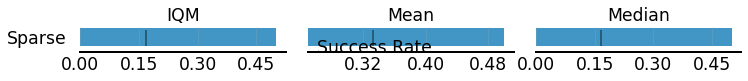

In [64]:
# plot the success rate and mean return confidence interval
aggregate_func = lambda x: np.array([
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_median(x),
])

aggregate_success_rate, aggregate_success_cis = rly.get_interval_estimates(
    final_aggregate_success_rates,
    aggregate_func,
    reps=50000,
)
pprint.pp(aggregate_success_cis)
fig, axes = plot_utils.plot_interval_estimates(
  aggregate_success_rate, aggregate_success_cis,
  metric_names=['IQM', 'Mean', 'Median'],
  color_palette=color_palette,
  algorithms=list(final_aggregate_success_rates.keys()), xlabel='Success Rate')

plt.show()

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint

# --- Configuration ---
# Set to True to interpolate runs onto a common timestep axis
INTERPOLATE_HISTORY = True
# Number of points for the common timestep axis if interpolating
NUM_INTERPOLATION_POINTS = 10
# Maximum timestep for the common axis (adjust based on your experiment lengths)
# Ensure this covers the range of 'num_timesteps' in your data
MAX_INTERPOLATION_STEP = 100_000

# --- Initialize Output Dictionaries ---
# These will store arrays of shape (num_runs, num_common_timesteps) if interpolating
# Or lists of the original DataFrames if not interpolating.
processed_success_history = dict()
processed_reward_history = dict()
common_timesteps = None # Will be defined if interpolating

print("Processing history data...")

# --- Interpolation Logic ---
if INTERPOLATE_HISTORY:
    # Check if previous aggregation was successful and produced valid tasks/run count
    if not valid_tasks or num_runs == 0:
         print("  Skipping history interpolation: No valid tasks or runs found in previous aggregation step.")
    else:
        common_timesteps = np.linspace(0, MAX_INTERPOLATION_STEP, NUM_INTERPOLATION_POINTS)
        print(f"Interpolation enabled: Using {NUM_INTERPOLATION_POINTS} points up to timestep {MAX_INTERPOLATION_STEP:.2E}.")

        # Iterate through methods that passed the previous aggregation step
        # Use final_aggregate_success_rates keys as the list of methods with consistent runs for valid tasks
        for method_name in final_aggregate_success_rates.keys():
            print(f"  Interpolating method: {method_name}")
            processed_success_history[method_name] = {}
            processed_reward_history[method_name] = {}

            # Iterate through the tasks deemed valid in the previous step
            for task_idx, task_name in enumerate(valid_tasks):
                print(f"    Task: {task_name}")
                # Get the list of history DFs for this method/task
                # Use .get for safety, though they should exist if method/task is valid
                success_histories_list = method_task_success_history.get(method_name, {}).get(task_name, [])
                reward_histories_list = method_task_reward_history.get(method_name, {}).get(task_name, [])

                interpolated_success_runs = []
                interpolated_reward_runs = []
                run_processing_successful = True

                # Check if the number of history series matches the expected number of runs
                if len(success_histories_list) != num_runs:
                     print(f"      Warning: Mismatch between expected runs ({num_runs}) and found success histories ({len(success_histories_list)}). Skipping history processing for this task/method.")
                     run_processing_successful = False
                     continue # Skip this task for this method's history
                if len(reward_histories_list) != num_runs:
                     print(f"      Warning: Mismatch between expected runs ({num_runs}) and found reward histories ({len(reward_histories_list)}). Skipping history processing for this task/method.")
                     run_processing_successful = False
                     continue # Skip this task for this method's history

                for run_idx in range(num_runs):
                    # --- Interpolate Success Rate ---
                    df_succ = success_histories_list[run_idx]
                    if df_succ is not None and not df_succ.empty and 'num_timesteps' in df_succ.columns and 'eval/success_rate' in df_succ.columns:
                        x = df_succ['num_timesteps'].values
                        y = df_succ['eval/success_rate'].values
                        # np.interp needs x to be monotonically increasing. Sort if necessary.
                        sort_idx = np.argsort(x)
                        x_sorted = x[sort_idx]
                        y_sorted = y[sort_idx]
                        # Handle cases where x might not be unique after sorting (rare)
                        unique_x, unique_idx = np.unique(x_sorted, return_index=True)
                        if len(unique_x) > 1: # Need at least two points to interpolate
                            interpolated_y = np.interp(common_timesteps, unique_x, y_sorted[unique_idx], left=y_sorted[unique_idx[0]], right=y_sorted[unique_idx[-1]])
                            interpolated_success_runs.append(interpolated_y)
                        elif len(unique_x) == 1: # Only one point, extrapolate constant value
                             print(f"      Info: Only one unique timestep ({unique_x[0]}) found for success run {run_idx}. Extrapolating constant value {y_sorted[unique_idx[0]]}.")
                             interpolated_success_runs.append(np.full(NUM_INTERPOLATION_POINTS, y_sorted[unique_idx[0]]))
                        else: # No valid points
                            print(f"      Warning: No valid data points found for success history run {run_idx}. Appending NaNs.")
                            interpolated_success_runs.append(np.full(NUM_INTERPOLATION_POINTS, np.nan))
                    else:
                        print(f"      Warning: Empty or invalid success history DataFrame for run {run_idx}. Appending NaNs.")
                        interpolated_success_runs.append(np.full(NUM_INTERPOLATION_POINTS, np.nan))

                    # --- Interpolate Eval Reward ---
                    df_rew = reward_histories_list[run_idx]
                    if df_rew is not None and not df_rew.empty and 'num_timesteps' in df_rew.columns and 'eval/mean_reward' in df_rew.columns:
                        x = df_rew['num_timesteps'].values
                        y = df_rew['eval/mean_reward'].values
                        sort_idx = np.argsort(x)
                        x_sorted = x[sort_idx]
                        y_sorted = y[sort_idx]
                        unique_x, unique_idx = np.unique(x_sorted, return_index=True)
                        if len(unique_x) > 1:
                            interpolated_y = np.interp(common_timesteps, unique_x, y_sorted[unique_idx], left=y_sorted[unique_idx[0]], right=y_sorted[unique_idx[-1]])
                            interpolated_reward_runs.append(interpolated_y)
                        elif len(unique_x) == 1:
                            print(f"      Info: Only one unique timestep ({unique_x[0]}) found for reward run {run_idx}. Extrapolating constant value {y_sorted[unique_idx[0]]}.")
                            interpolated_reward_runs.append(np.full(NUM_INTERPOLATION_POINTS, y_sorted[unique_idx[0]]))
                        else:
                            print(f"      Warning: No valid data points found for reward history run {run_idx}. Appending NaNs.")
                            interpolated_reward_runs.append(np.full(NUM_INTERPOLATION_POINTS, np.nan))
                    else:
                        print(f"      Warning: Empty or invalid reward history DataFrame for run {run_idx}. Appending NaNs.")
                        interpolated_reward_runs.append(np.full(NUM_INTERPOLATION_POINTS, np.nan))

                # Store results as numpy arrays for the task if all runs processed
                if run_processing_successful and len(interpolated_success_runs) == num_runs:
                    processed_success_history[method_name][task_name] = np.array(interpolated_success_runs)
                if run_processing_successful and len(interpolated_reward_runs) == num_runs:
                    processed_reward_history[method_name][task_name] = np.array(interpolated_reward_runs)

# --- Handling for No Interpolation ---
elif not INTERPOLATE_HISTORY:
    print("Interpolation disabled. Storing original history DataFrames for valid methods and tasks.")
    # Just copy the relevant parts from the original history dictionaries
    if not valid_tasks:
         print("  No valid tasks found in previous step. No history data processed.")
    else:
        for method_name in final_aggregate_success_rates.keys(): # Use methods that passed aggregation
            processed_success_history[method_name] = {}
            processed_reward_history[method_name] = {}
            print(f"  Storing original histories for method: {method_name}")
            for task_name in valid_tasks: # Use tasks that passed validation
                 # Only store if the original list is not empty and matches expected run count
                 success_list = method_task_success_history.get(method_name, {}).get(task_name, [])
                 reward_list = method_task_reward_history.get(method_name, {}).get(task_name, [])
                 if len(success_list) == num_runs:
                      processed_success_history[method_name][task_name] = success_list
                 else:
                      print(f"    Warning: Skipping success history for task '{task_name}' due to run count mismatch (expected {num_runs}, got {len(success_list)}).")
                 if len(reward_list) == num_runs:
                      processed_reward_history[method_name][task_name] = reward_list
                 else:
                      print(f"    Warning: Skipping reward history for task '{task_name}' due to run count mismatch (expected {num_runs}, got {len(reward_list)}).")


# --- Print Structure Summary ---
print("\n" + "=" * 30)
print("Processed History Data Summary:")
print(f"Interpolation Applied: {INTERPOLATE_HISTORY}")
print("=" * 30)

if not processed_success_history:
     print("\nNo history data was processed (check validation steps and INTERPOLATE_HISTORY flag).")
else:
    for method_name in processed_success_history.keys():
        print(f"\nMethod: {method_name}")
        processed_tasks = list(processed_success_history[method_name].keys())
        print(f"  Tasks Processed ({len(processed_tasks)}): {processed_tasks}")

        if INTERPOLATE_HISTORY and processed_tasks:
            first_task = processed_tasks[0]
            # Check if data actually exists for the first task before accessing shape
            if first_task in processed_success_history[method_name] and processed_success_history[method_name][first_task] is not None:
                 print(f"  Success History Shape (e.g., {first_task}): {processed_success_history[method_name][first_task].shape}")
            else:
                 print(f"  Success History Shape (e.g., {first_task}): N/A")

            if first_task in processed_reward_history[method_name] and processed_reward_history[method_name][first_task] is not None:
                 print(f"  Reward History Shape (e.g., {first_task}): {processed_reward_history[method_name][first_task].shape}")
            else:
                 print(f"  Reward History Shape (e.g., {first_task}): N/A")

            if common_timesteps is not None:
                 print(f"  (Shape: num_runs x num_common_timesteps), Timesteps: {common_timesteps.shape}")

        elif not INTERPOLATE_HISTORY and processed_tasks:
            first_task = processed_tasks[0]
            num_dfs = len(processed_success_history[method_name].get(first_task, [])) # Use get for safety
            print(f"  Stored {num_dfs} original history DataFrames per task (if available).")

print("\nAccess data using e.g., `processed_success_history['Sparse']['button-press-wall-v2']`")
if INTERPOLATE_HISTORY and common_timesteps is not None:
    print("Common timesteps used for interpolation are in the `common_timesteps` variable.")
print("=" * 30)

Processing history data...
Interpolation enabled: Using 10 points up to timestep 1.00E+05.
  Interpolating method: Sparse
    Task: button-press-wall-v2
    Task: coffee-button-v2
    Task: reach-wall-v2
    Task: window-close-v2

Processed History Data Summary:
Interpolation Applied: True

Method: Sparse
  Tasks Processed (4): ['button-press-wall-v2', 'coffee-button-v2', 'reach-wall-v2', 'window-close-v2']
  Success History Shape (e.g., button-press-wall-v2): (3, 10)
  Reward History Shape (e.g., button-press-wall-v2): (3, 10)
  (Shape: num_runs x num_common_timesteps), Timesteps: (10,)

Access data using e.g., `processed_success_history['Sparse']['button-press-wall-v2']`
Common timesteps used for interpolation are in the `common_timesteps` variable.


In [53]:
pprint.pp(processed_success_history['Sparse']['button-press-wall-v2'].shape)

(3, 10)


In [54]:
# now, aggregate the success history across all tasks for each method
aggregate_success_history = {}
for method_name in processed_success_history.keys():
    aggregate_success_history[method_name] = []
    for task_name in processed_success_history[method_name].keys():
        aggregate_success_history[method_name].append(processed_success_history[method_name][task_name])
    aggregate_success_history[method_name] = np.array(aggregate_success_history[method_name])
pprint.pp(aggregate_success_history["Sparse"].shape)

# now, aggregate the reward history across all tasks for each method
aggregate_reward_history = {}
for method_name in processed_reward_history.keys():
    aggregate_reward_history[method_name] = []
    for task_name in processed_reward_history[method_name].keys():
        aggregate_reward_history[method_name].append(processed_reward_history[method_name][task_name])
    aggregate_reward_history[method_name] = np.array(aggregate_reward_history[method_name])

# num tasks x num runs x num timesteps


(4, 3, 10)


<Axes: xlabel='Number of Timesteps', ylabel='IQM Success Rate'>

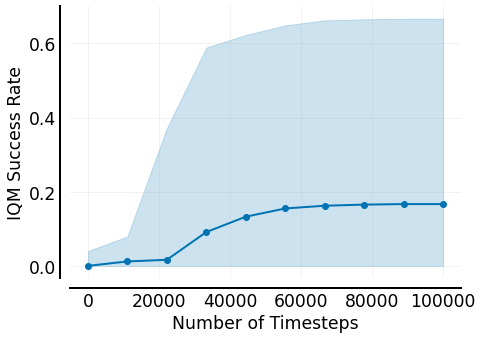

In [66]:
iqm = lambda scores: np.array([metrics.aggregate_iqm(scores[..., frame])
                               for frame in range(scores.shape[-1])])
iqm_scores, iqm_cis = rly.get_interval_estimates(
  aggregate_success_history, iqm, reps=50000)
plot_utils.plot_sample_efficiency_curve(
    common_timesteps, iqm_scores, iqm_cis, algorithms=list(aggregate_success_history.keys()),
    color_palette=color_palette,
    xlabel=r'Number of Timesteps',
    ylabel='IQM Success Rate')

TypeError: list indices must be integers or slices, not str

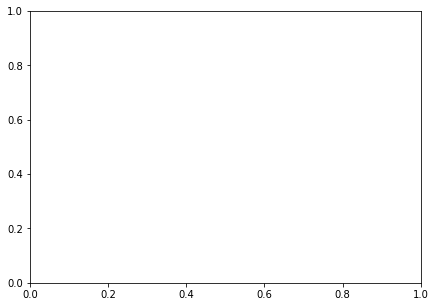

In [70]:
# now, plot the reward history
iqm = lambda scores: np.array([metrics.aggregate_iqm(scores[..., frame])
                               for frame in range(scores.shape[-1])])
iqm_scores, iqm_cis = rly.get_interval_estimates(
  aggregate_reward_history, iqm, reps=50000)
plot_utils.plot_sample_efficiency_curve(
    common_timesteps, iqm_scores, iqm_cis, algorithms=list(aggregate_reward_history.keys()),
    colors=color_palette,
    xlabel=r'Number of Timesteps',
    ylabel='IQM Eval Return')